In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator
import numpy as np
import matplotlib.ticker as ticker
import json
import os

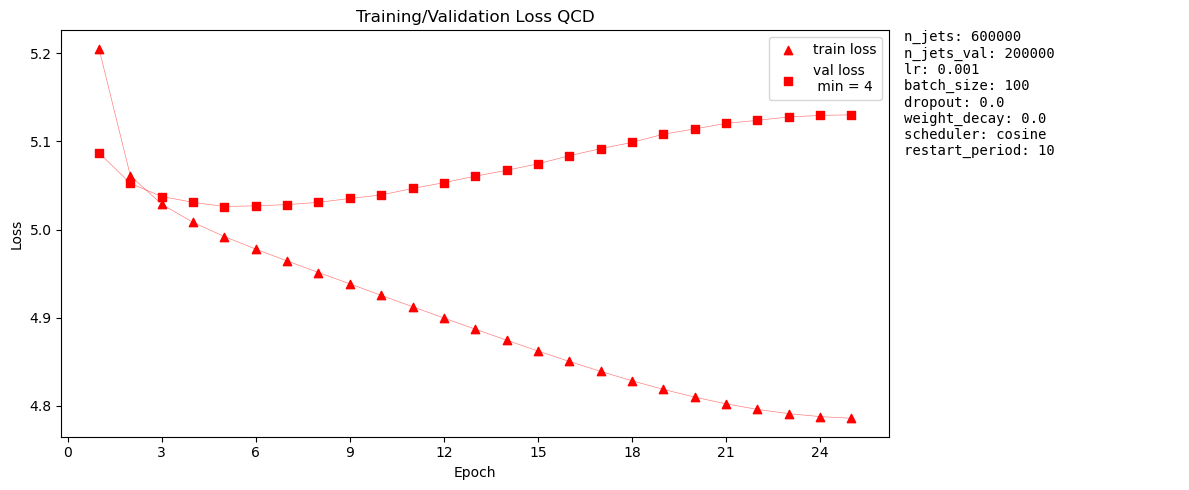

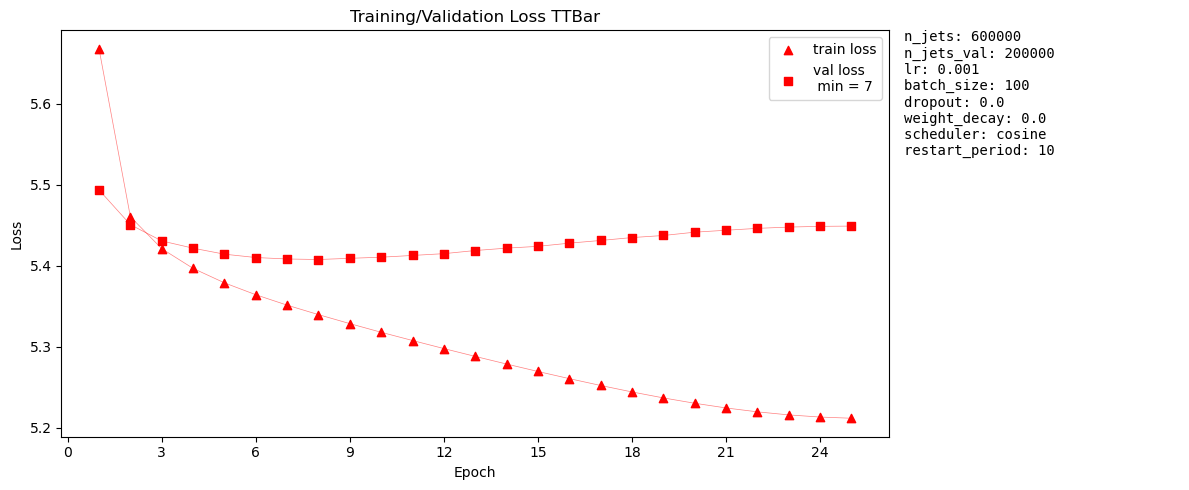

In [2]:
DATASET = "JETCLASS"
SCHEDULER = "cosine_restarts"
N_JETS = 600000

#modify name for specific traings run
base_train = "/hpcwork/rwth0934/hep_foundation_model/training"
trainings_run = f"600000_overfitting"

folder = f"{base_train}/{trainings_run}"

CLASSES = ["QCD", "TTBar"]

for CLASS in CLASSES:


    config_path = os.path.join(folder, f"{CLASS}_config.json")

    with open(config_path, "r") as f:
        config = json.load(f)

    important_keys = [
        "n_jets",
        "n_jets_val",
        "lr",
        "batch_size",
        "dropout",
        "weight_decay",
        "scheduler",
        "restart_period",
    ]

    param_text = "\n".join([f"{k}: {config[k]}" for k in important_keys if k in config])

    EPOCH_STEPS = N_JETS / config["batch_size"]

    fig, (ax_plot, ax_text) = plt.subplots(
        1, 2,
        figsize=(12, 5),
        gridspec_kw={"width_ratios": [3, 1]}
    )

    data = pd.read_csv(f"{folder}/{CLASS}_training_log.csv")

    data["epoch"] = data["step"] / EPOCH_STEPS
    data_min = np.argmin(data["val_loss"])


    # ---- Loss plot ---
    ax_plot.scatter(data["epoch"], data["train_loss"], label="train loss",
           color = "red",
           marker = "^")
    ax_plot.scatter(data["epoch"], data["val_loss"], label=f"val loss \n min = {data_min}",
            color = "red",
            marker = "s")

    ax_plot.plot(data["epoch"], data["train_loss"],
            color = "red",
            linewidth = 0.5,
            alpha = 0.5)
    ax_plot.plot(data["epoch"], data["val_loss"],
            color = "red",
            linewidth = 0.5,
            alpha = 0.5)


    ax_plot.set_xlabel("Epoch")
    ax_plot.set_ylabel("Loss")
    ax_plot.legend()

    # ---- Text panel ----
    ax_text.axis("off")  # remove axes

    ax_text.text(
        0, 1,
        param_text,
        fontsize=10,
        va="top",
        family="monospace"
    )

    ax_plot.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    #ax.set_yscale("log")
    ax_plot.set_title(f"Training/Validation Loss {CLASS}")

    fig.savefig(f"plots/{trainings_run}_{CLASS}.png", dpi = 150, bbox_inches = "tight")

    plt.tight_layout()
    plt.show()

os.makedirs("plots", exist_ok=True)

plt.show()